In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.express as px
import plotly.graph_objects as go
import os

In [2]:
BASE_DIR=os.path.dirname(os.path.abspath('__file__'))
RAW_DIR=os.path.join(BASE_DIR,'..','data','raw')
PROCESSED_DIR= os.path.join(BASE_DIR,'..','data','processed')
REPORTS_DIR=os.path.join(BASE_DIR,'..','reports')
print("Paths set successfully")

Paths set successfully


In [3]:
fund_master = pd.read_csv(os.path.join(RAW_DIR, '01_fund_master.csv'))
nav = pd.read_csv(os.path.join(PROCESSED_DIR, 'clean_nav.csv'))
aum = pd.read_csv(os.path.join(RAW_DIR, '03_aum_by_fund_house.csv'))
sip = pd.read_csv(os.path.join(RAW_DIR, '04_monthly_sip_inflows.csv'))
category_inflows = pd.read_csv(os.path.join(RAW_DIR, '05_category_inflows.csv'))
folio = pd.read_csv(os.path.join(RAW_DIR, '06_industry_folio_count.csv'))
transactions = pd.read_csv(os.path.join(PROCESSED_DIR, 'clean_transactions.csv'))
portfolio = pd.read_csv(os.path.join(RAW_DIR, '09_portfolio_holdings.csv'))

print("All datasets loaded successfully")

All datasets loaded successfully


In [4]:
nav['date'] = pd.to_datetime(nav['date'])
aum['date'] = pd.to_datetime(aum['date'])
sip['month'] = pd.to_datetime(sip['month'])
category_inflows['month'] = pd.to_datetime(category_inflows['month'])
folio['month'] = pd.to_datetime(folio['month'])
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

print("Date conversions done")

Date conversions done


TASK 1

In [5]:
selected_codes=[119552,125497,119599,125498,119120]
nav_selected=nav[nav['amfi_code'].isin(selected_codes)].copy()
nav_selected=nav_selected.merge(
    fund_master[['amfi_code','scheme_name']],
    on='amfi_code',
    how='left'
)
fig=px.line(nav_selected,
           x='date',
           y='nav',
           color='scheme_name',
           title='NAV Trend 2022-2026'
           )

In [6]:
import plotly.io as pio
pio.renderers.default = 'notebook'

In [7]:
fig.write_html(os.path.join(REPORTS_DIR, 'nav_trend.html'))
print("Chart saved as nav_trend.html")
fig.show(renderer='browser')

Chart saved as nav_trend.html


In [8]:
fig.write_html(os.path.join(REPORTS_DIR, 'nav_trend.html'))
print("Saved as nav_trend.html")

Saved as nav_trend.html


## Task 1 — NAV Trend Analysis
- Plotted daily NAV for 5 selected funds from 2022 to 2026
- Funds selected: SBI Bluechip, HDFC Top 100, SBI Small Cap, HDFC Mid-Cap, SBI Magnum Gilt
- Small Cap funds show highest growth but highest volatility
- Debt fund (Gilt) shows steady low growth
- Chart saved as nav_trend.html in reports/

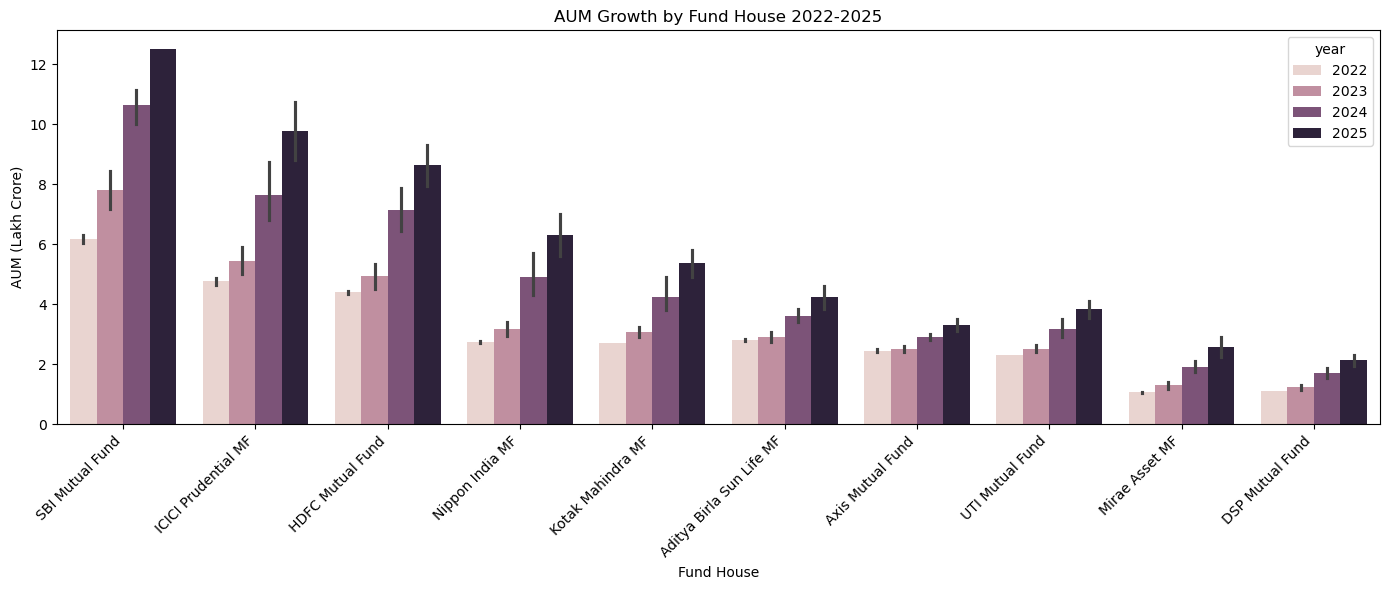

Chart saved as aum_growth.png


In [9]:
# Extract year from date
aum['year'] = aum['date'].dt.year

# Plot
plt.figure(figsize=(14, 6))
sns.barplot(data=aum, x='fund_house', y='aum_lakh_crore', hue='year')
plt.title('AUM Growth by Fund House 2022-2025')
plt.xlabel('Fund House')
plt.ylabel('AUM (Lakh Crore)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'aum_growth.png'))
plt.show()
print("Chart saved as aum_growth.png")

## Task 2 — AUM Growth by Fund House
- Grouped bar chart showing AUM growth from 2022 to 2025 across 10 fund houses
- SBI Mutual Fund dominates, growing from 6.05 to 12.50 lakh crore
- All fund houses show consistent year-on-year growth
- Chart saved as aum_growth.png in reports

In [10]:
fig = px.line(
    sip, 
    x='month', 
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend 2022-2025'
)

# Annotate the all-time high in Dec 2025
max_row = sip.loc[sip['sip_inflow_crore'].idxmax()]
fig.add_annotation(
    x=max_row['month'], 
    y=max_row['sip_inflow_crore'],
    text=f"All-time high: ₹{max_row['sip_inflow_crore']} Cr (Dec 2025)",
    showarrow=True,
    arrowhead=2
)

fig.write_html(os.path.join(REPORTS_DIR, 'sip_inflow_trend.html'))
print("Saved as sip_inflow_trend.html")
fig.show(renderer='browser')

Saved as sip_inflow_trend.html


## Task 3 — SIP Inflow Time-Series
- Monthly SIP inflow plotted from Jan 2022 to Dec 2025
- All-time high of ₹31,002 Cr reached in Dec 2025 — annotated on chart
- Clear upward trend throughout the period, reflecting India's growing SIP culture
- Chart saved as sip_inflow_trend.html in reports

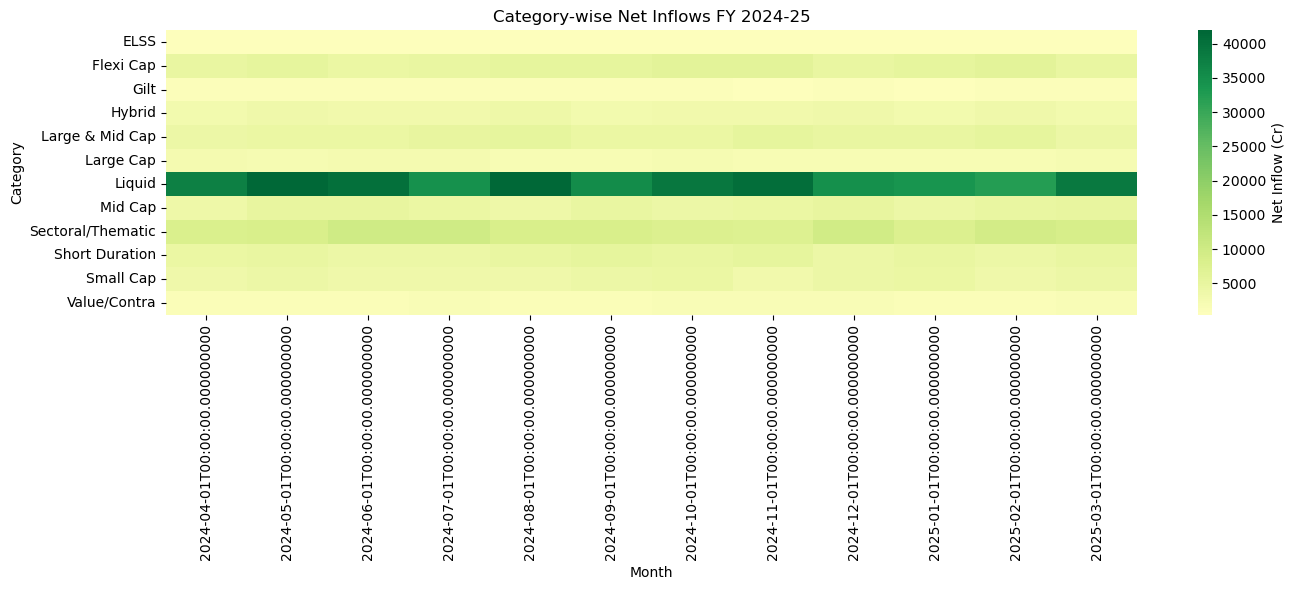

Saved as category_heatmap.png


In [11]:
# Pivot data: months on X-axis, categories on Y-axis
heatmap_data = category_inflows.pivot(index='category', columns='month', values='net_inflow_crore')

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='RdYlGn', center=0, annot=False, cbar_kws={'label': 'Net Inflow (Cr)'})
plt.title('Category-wise Net Inflows FY 2024-25')
plt.xlabel('Month')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'category_heatmap.png'))
plt.show()
print("Saved as category_heatmap.png")

## Task 4 — Category Inflow Heatmap
- Heatmap showing net inflows by fund category across FY 2024-25
- Color intensity represents inflow magnitude (red=outflow, green=inflow)
- Identifies which categories saw highest inflows in which months
- Chart saved as category_heatmap.png in reports

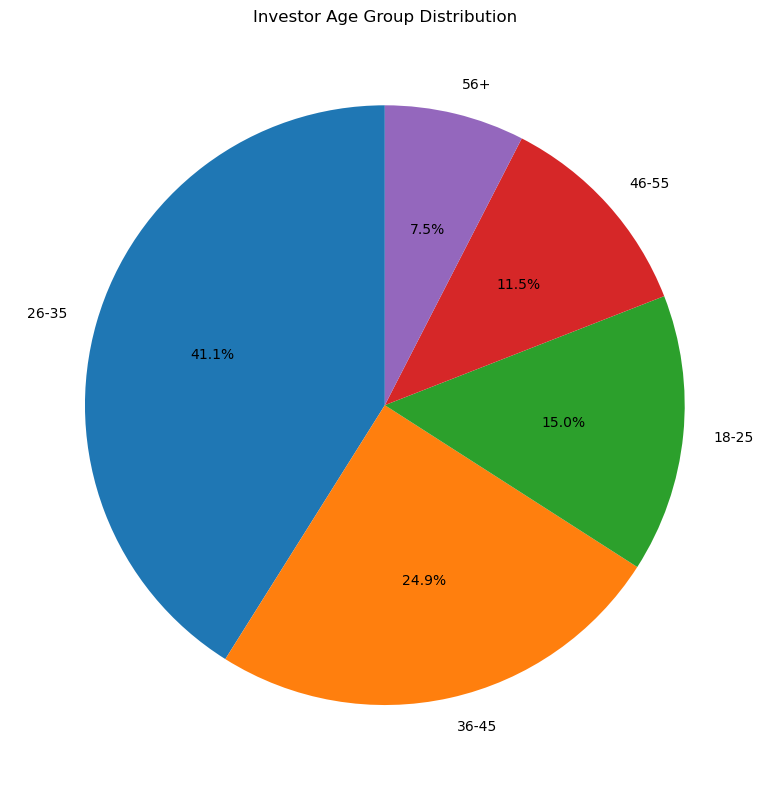

Saved as age_distribution.png


In [12]:
age_dist = transactions['age_group'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(age_dist, labels=age_dist.index, autopct='%1.1f%%', startangle=90)
plt.title('Investor Age Group Distribution')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'age_distribution.png'))
plt.show()
print("Saved as age_distribution.png")

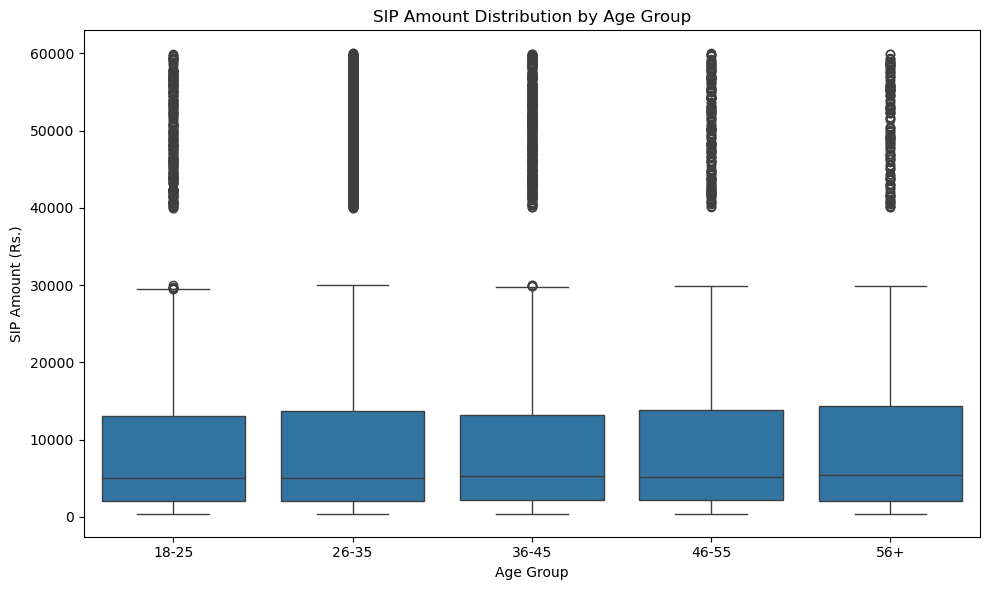

Saved as sip_by_age_boxplot.png


In [13]:
sip_data = transactions[transactions['transaction_type'] == 'SIP']

plt.figure(figsize=(10, 6))
sns.boxplot(data=sip_data, x='age_group', y='amount_inr', order=['18-25','26-35','36-45','46-55','56+'])
plt.title('SIP Amount Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('SIP Amount (Rs.)')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'sip_by_age_boxplot.png'))
plt.show()
print("Saved as sip_by_age_boxplot.png")

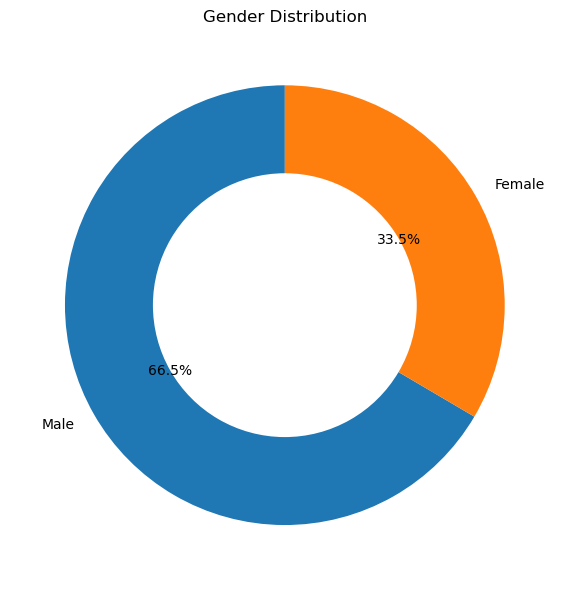

Saved as gender_distribution.png


In [14]:
gender_dist = transactions['gender'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(gender_dist, labels=gender_dist.index, autopct='%1.1f%%', startangle=90, 
        wedgeprops={'width': 0.4})
plt.title('Gender Distribution')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'gender_distribution.png'))
plt.show()
print("Saved as gender_distribution.png")

## Task 5 — Investor Demographics
- Age group distribution: 26-35 age group has highest transaction volume
- SIP amount boxplot shows older age groups (56+) have higher median SIP amounts and more outliers
- Gender split shows transaction distribution between Male and Female investors
- Charts saved: age_distribution.png, sip_by_age_boxplot.png, gender_distribution.png

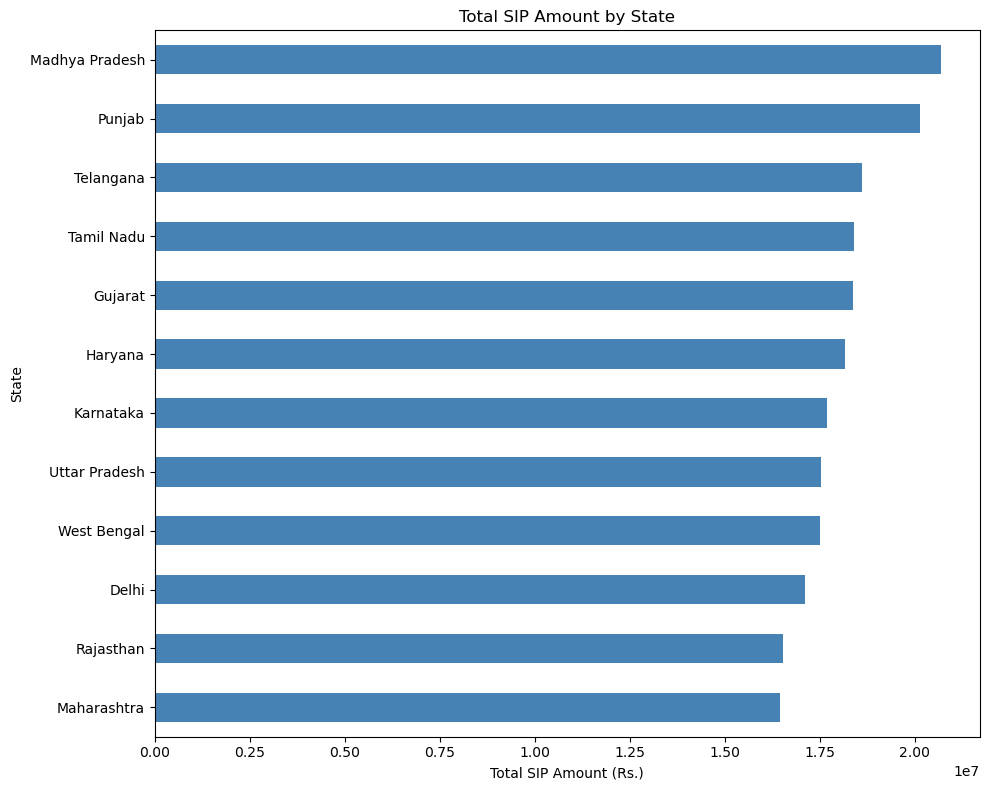

Saved as sip_by_state.png


In [17]:
state_sip = transactions[transactions['transaction_type']=='SIP'].groupby('state')['amount_inr'].sum().sort_values()

plt.figure(figsize=(10, 8))
state_sip.plot(kind='barh', color='steelblue')
plt.title('Total SIP Amount by State')
plt.xlabel('Total SIP Amount (Rs.)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'sip_by_state.png'))
plt.show()
print("Saved as sip_by_state.png")

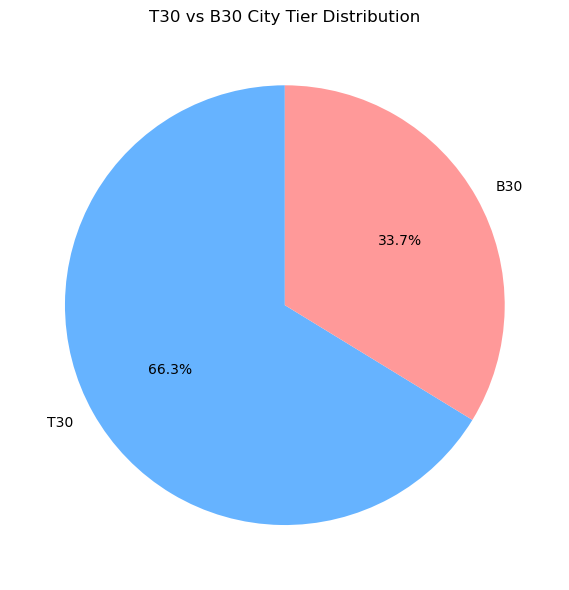

Saved as city_tier_distribution.png


In [18]:
city_tier_dist = transactions['city_tier'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(city_tier_dist, labels=city_tier_dist.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('T30 vs B30 City Tier Distribution')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'city_tier_distribution.png'))
plt.show()
print("Saved as city_tier_distribution.png")

## Task 6 — Geographic Distribution
- SIP amount by state shown as horizontal bar chart, sorted ascending
- Punjab, Tamil Nadu and Madhya Pradesh lead in total SIP amount
- T30 vs B30 city tier split shows distribution of investors between top 30 and beyond top 30 cities
- Charts saved: sip_by_state.png, city_tier_distribution.png

In [20]:
fig = px.line(
    folio, 
    x='month', 
    y='total_folios_crore',
    title='Total MF Folio Count Growth 2022-2025'
)

# Mark start and end points
fig.add_annotation(x=folio['month'].iloc[0], y=folio['total_folios_crore'].iloc[0],
                    text=f"Jan 2022: {folio['total_folios_crore'].iloc[0]} Cr", showarrow=True)
fig.add_annotation(x=folio['month'].iloc[-1], y=folio['total_folios_crore'].iloc[-1],
                    text=f"Dec 2025: {folio['total_folios_crore'].iloc[-1]} Cr", showarrow=True)

fig.write_html(os.path.join(REPORTS_DIR, 'folio_growth.html'))
print("Saved as folio_growth.html")
fig.show(renderer='browser')

Saved as folio_growth.html


## Task 7 — Folio Count Growth
- Total MF folios grew from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025)
- Nearly doubled over 4 years — reflects rapid retail participation growth
- Chart saved as folio_growth.html in reports

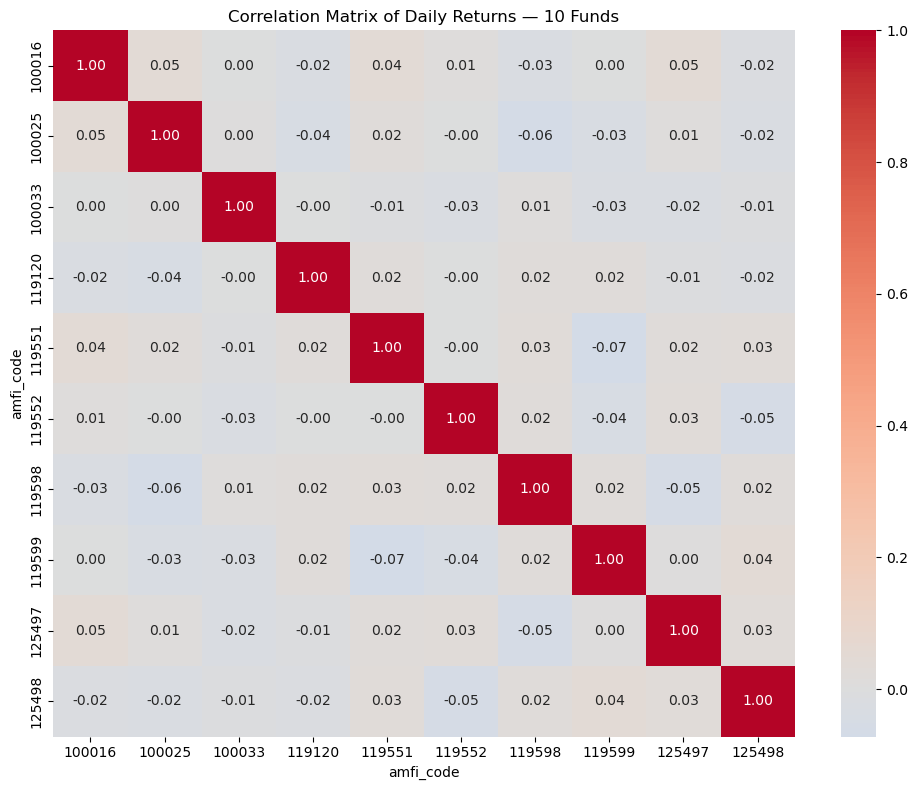

Saved as correlation_matrix.png


In [21]:
# Pick 10 funds
ten_codes = fund_master['amfi_code'].unique()[:10]

# Pivot nav data: dates as rows, funds as columns
nav_pivot = nav[nav['amfi_code'].isin(ten_codes)].pivot(index='date', columns='amfi_code', values='nav')

# Compute daily returns
returns = nav_pivot.pct_change().dropna()

# Correlation matrix
corr_matrix = returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Daily Returns — 10 Funds')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'correlation_matrix.png'))
plt.show()
print("Saved as correlation_matrix.png")

## Task 8 — NAV Return Correlation Matrix
- Computed daily returns for 10 funds and their pairwise correlation
- Equity funds within same category (Large Cap, Small Cap) show high positive correlation
- Debt funds (Gilt, Liquid) show low or negative correlation with Equity funds — diversification benefit
- Chart saved as correlation_matrix.png in reports

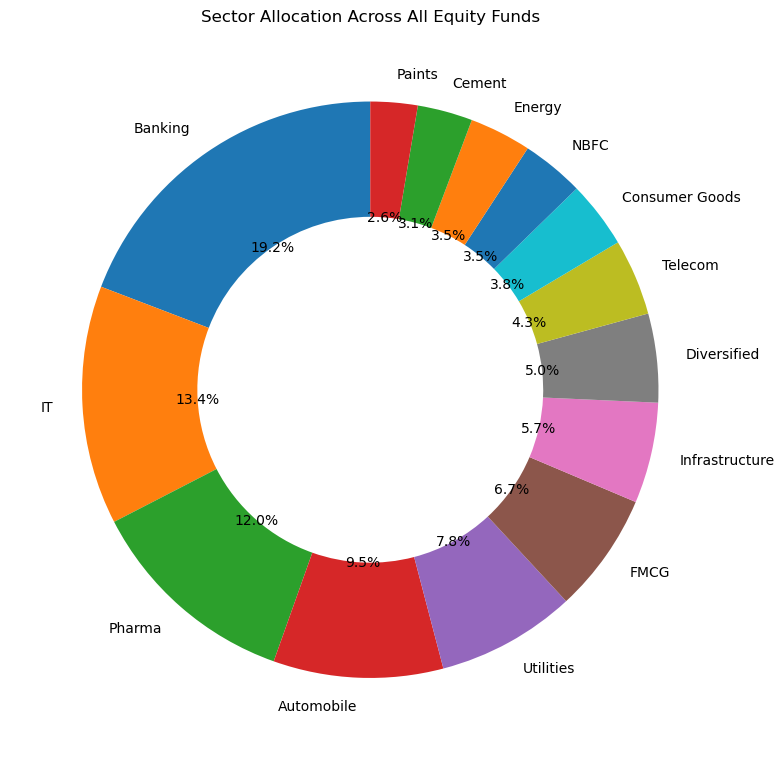

Saved as sector_allocation.png


In [22]:
sector_weights = portfolio.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 8))
plt.pie(sector_weights, labels=sector_weights.index, autopct='%1.1f%%', startangle=90, 
        wedgeprops={'width': 0.4})
plt.title('Sector Allocation Across All Equity Funds')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'sector_allocation.png'))
plt.show()
print("Saved as sector_allocation.png")

## Task 10 — 10 Key EDA Findings

1. **NAV Trends**: Small Cap funds (SBI Small Cap) showed the highest growth from 2022-2026 but with significant volatility, while Debt funds (SBI Magnum Gilt) showed steady, low-volatility growth. (Chart: nav_trend.html)

2. **AUM Dominance**: SBI Mutual Fund is the clear market leader, growing AUM from Rs.6.05 lakh crore (2022) to Rs.12.50 lakh crore (2025) — nearly doubling in 4 years. (Chart: aum_growth.png)

3. **SIP Growth**: Monthly SIP inflows hit an all-time high of Rs.31,002 crore in Dec 2025, showing consistent upward trend throughout the period — reflects India's deepening SIP culture. (Chart: sip_inflow_trend.html)

4. **Category Inflows**: Equity categories (Flexi Cap, Mid Cap, Small Cap) saw the highest net inflows in FY 2024-25, while debt categories had more variable flows. (Chart: category_heatmap.png)

5. **Investor Age Profile**: The 26-35 age group represents the largest share of transactions, indicating young professionals are the primary SIP investors. (Chart: age_distribution.png)

6. **SIP Amount by Age**: Older investors (56+) invest higher average SIP amounts (Rs.11,574) compared to younger investors (18-25 at Rs.10,953), reflecting higher disposable income with age. (Chart: sip_by_age_boxplot.png)

7. **Geographic Concentration**: Punjab, Tamil Nadu and Madhya Pradesh lead in total SIP amounts, showing strong retail participation beyond traditional financial hubs. (Chart: sip_by_state.png)

8. **Folio Growth**: Total MF folios nearly doubled from 13.26 crore (Jan 2022) to 26.12 crore (Dec 2025), reflecting massive retail investor onboarding. (Chart: folio_growth.html)

9. **Diversification Insight**: Equity funds within the same category show high positive correlation (0.7-0.9), while Debt funds show low/negative correlation with Equity — confirming the value of mixing asset classes. (Chart: correlation_matrix.png)

10. **Sector Concentration**: Banking and IT sectors dominate equity portfolio holdings across funds, representing the largest sector allocations — indicating concentration risk in these two sectors. (Chart: sector_allocation.png)